# ColBERT v2: Understanding Late Interaction Retrieval
*AI Tinkerers Presentation*

---

## 1. What is ColBERT?

**ColBERT** = **C**ontextualized **L**ate Interaction **o**ver **BERT**

### Traditional Dense Retrieval vs ColBERT

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Traditional Dense Retrieval
print("🔵 TRADITIONAL DENSE RETRIEVAL")
print("Query: 'python tutorial' → Single vector [0.2, 0.8, 0.1, 0.9]")
print("Document: 'Learn Python basics' → Single vector [0.3, 0.7, 0.2, 0.8]")
print("Similarity: cosine(query_vector, doc_vector) = 0.85")
print()

# ColBERT Late Interaction
print("🟢 ColBERT LATE INTERACTION")
print("Query: 'python tutorial' → Matrix of token vectors")
print("  'python'   → [0.2, 0.8, 0.1, 0.9]")
print("  'tutorial' → [0.1, 0.9, 0.3, 0.7]")
print()
print("Document: 'Learn Python basics' → Matrix of token vectors")
print("  'Learn'  → [0.4, 0.6, 0.2, 0.5]")
print("  'Python' → [0.2, 0.8, 0.1, 0.9]")
print("  'basics' → [0.3, 0.5, 0.4, 0.6]")
print()
print("Interaction: Every query token compares to every doc token (MaxSim)")

🔵 TRADITIONAL DENSE RETRIEVAL
Query: 'python tutorial' → Single vector [0.2, 0.8, 0.1, 0.9]
Document: 'Learn Python basics' → Single vector [0.3, 0.7, 0.2, 0.8]
Similarity: cosine(query_vector, doc_vector) = 0.85

🟢 ColBERT LATE INTERACTION
Query: 'python tutorial' → Matrix of token vectors
  'python'   → [0.2, 0.8, 0.1, 0.9]
  'tutorial' → [0.1, 0.9, 0.3, 0.7]

Document: 'Learn Python basics' → Matrix of token vectors
  'Learn'  → [0.4, 0.6, 0.2, 0.5]
  'Python' → [0.2, 0.8, 0.1, 0.9]
  'basics' → [0.3, 0.5, 0.4, 0.6]

Interaction: Every query token compares to every doc token (MaxSim)


### Key Insight: Token-level matching captures fine-grained semantic relationships!

In [2]:
# Demonstrate MaxSim calculation
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Query tokens
python_token = np.array([0.2, 0.8, 0.1, 0.9])
tutorial_token = np.array([0.1, 0.9, 0.3, 0.7])

# Document tokens
learn_token = np.array([0.4, 0.6, 0.2, 0.5])
Python_token = np.array([0.2, 0.8, 0.1, 0.9])  # Notice: same as query "python"!
basics_token = np.array([0.3, 0.5, 0.4, 0.6])

doc_tokens = [learn_token, Python_token, basics_token]
doc_names = ['Learn', 'Python', 'basics']

print("ColBERT MaxSim Calculation:")
print("\n'python' query token vs all document tokens:")
python_similarities = []
for i, doc_token in enumerate(doc_tokens):
    sim = cosine_similarity(python_token, doc_token)
    python_similarities.append(sim)
    print(f"  vs '{doc_names[i]}': {sim:.3f}")

python_maxsim = max(python_similarities)
print(f"MaxSim for 'python': {python_maxsim:.3f}")

print("\n'tutorial' query token vs all document tokens:")
tutorial_similarities = []
for i, doc_token in enumerate(doc_tokens):
    sim = cosine_similarity(tutorial_token, doc_token)
    tutorial_similarities.append(sim)
    print(f"  vs '{doc_names[i]}': {sim:.3f}")

tutorial_maxsim = max(tutorial_similarities)
print(f"MaxSim for 'tutorial': {tutorial_maxsim:.3f}")

total_score = python_maxsim + tutorial_maxsim
print(f"\n🎯 Final ColBERT Score: {python_maxsim:.3f} + {tutorial_maxsim:.3f} = {total_score:.3f}")

ColBERT MaxSim Calculation:

'python' query token vs all document tokens:
  vs 'Learn': 0.934
  vs 'Python': 1.000
  vs 'basics': 0.916
MaxSim for 'python': 1.000

'tutorial' query token vs all document tokens:
  vs 'Learn': 0.930
  vs 'Python': 0.966
  vs 'basics': 0.930
MaxSim for 'tutorial': 0.966

🎯 Final ColBERT Score: 1.000 + 0.966 = 1.966


---

## 2. ColBERT v1 Problems

### Problem 1: Storage Explosion 💥

In [3]:
# Storage comparison
print("📊 STORAGE COMPARISON")
print()

# Traditional dense retrieval
dense_vectors_per_doc = 1
dense_vector_size = 768  # typical BERT embedding size
dense_bytes_per_doc = dense_vectors_per_doc * dense_vector_size * 4  # 4 bytes per float32

print(f"Traditional Dense Retrieval:")
print(f"  • {dense_vectors_per_doc} vector per document")
print(f"  • {dense_vector_size} dimensions")
print(f"  • {dense_bytes_per_doc:,} bytes per document")
print()

# ColBERT v1
colbert_tokens_per_doc = 100  # average document length
colbert_vector_size = 128  # ColBERT uses smaller embeddings
colbert_bytes_per_doc = colbert_tokens_per_doc * colbert_vector_size * 4

print(f"ColBERT v1:")
print(f"  • {colbert_tokens_per_doc} vectors per document (one per token)")
print(f"  • {colbert_vector_size} dimensions each")
print(f"  • {colbert_bytes_per_doc:,} bytes per document")
print()

storage_explosion = colbert_bytes_per_doc / dense_bytes_per_doc
print(f"💥 Storage explosion: {storage_explosion:.1f}x more storage!")

# For 1M documents
num_docs = 1_000_000
dense_total_gb = (dense_bytes_per_doc * num_docs) / (1024**3)
colbert_total_gb = (colbert_bytes_per_doc * num_docs) / (1024**3)

print(f"\nFor {num_docs:,} documents:")
print(f"  • Dense retrieval: {dense_total_gb:.1f} GB")
print(f"  • ColBERT v1: {colbert_total_gb:.1f} GB")

📊 STORAGE COMPARISON

Traditional Dense Retrieval:
  • 1 vector per document
  • 768 dimensions
  • 3,072 bytes per document

ColBERT v1:
  • 100 vectors per document (one per token)
  • 128 dimensions each
  • 51,200 bytes per document

💥 Storage explosion: 16.7x more storage!

For 1,000,000 documents:
  • Dense retrieval: 2.9 GB
  • ColBERT v1: 47.7 GB


### Problem 2: Noisy Training Data 🗑️

In [4]:
print("🗑️ EXAMPLES OF NOISY TRAINING DATA")
print()

print("❌ Bad Auto-Generated Labels:")
print()

print("1. BM25 Keyword Matching:")
print("   Query: 'python tutorial'")
print("   Document: 'Basic machine for learning disabled children'")
print("   BM25 says: RELEVANT (matches 'basic' and 'learning')")
print("   Reality: Completely irrelevant!")
print()

print("2. Click-through Data:")
print("   User searches: 'machine learning tutorial'")
print("   Clicks on: 'Java vs Python comparison'")
print("   Leaves immediately (wrong result)")
print("   System learns: 'Java article relevant to ML tutorial'")
print()

print("3. Weak Supervision:")
print("   Old retrieval model says: Document X is relevant")
print("   Train new model on these labels")
print("   Result: Inherit all the old model's mistakes!")
print()

print("📈 Scale of the Problem:")
print(f"   • Need {10_000_000:,} training examples for good performance")
print(f"   • Manual labeling cost: ${10_000_000:,} at $1 per label")
print(f"   • Auto-labeling: ~30% wrong labels")
print(f"   • Result: ColBERT v1 learned from garbage data!")

🗑️ EXAMPLES OF NOISY TRAINING DATA

❌ Bad Auto-Generated Labels:

1. BM25 Keyword Matching:
   Query: 'python tutorial'
   Document: 'Basic machine for learning disabled children'
   BM25 says: RELEVANT (matches 'basic' and 'learning')
   Reality: Completely irrelevant!

2. Click-through Data:
   User searches: 'machine learning tutorial'
   Clicks on: 'Java vs Python comparison'
   Leaves immediately (wrong result)
   System learns: 'Java article relevant to ML tutorial'

3. Weak Supervision:
   Old retrieval model says: Document X is relevant
   Train new model on these labels
   Result: Inherit all the old model's mistakes!

📈 Scale of the Problem:
   • Need 10,000,000 training examples for good performance
   • Manual labeling cost: $10,000,000 at $1 per label
   • Auto-labeling: ~30% wrong labels
   • Result: ColBERT v1 learned from garbage data!


---

## 3. ColBERT v2 Solutions

### Innovation 1: Residual Compression

**The Idea:** Use clustering + quantization to compress token embeddings

In [5]:
print("🔧 RESIDUAL COMPRESSION - STEP BY STEP")
print()

# Original token embedding
original_embedding = np.array([0.8, 0.3, 0.1, 0.9])
print(f"Original token embedding: {original_embedding}")
print(f"Storage: {len(original_embedding) * 4} bytes (4 bytes per float32)")
print()

# Step 1: Split into chunks
chunk1 = original_embedding[:2]
chunk2 = original_embedding[2:]
print(f"Step 1 - Split into chunks:")
print(f"  Chunk 1: {chunk1}")
print(f"  Chunk 2: {chunk2}")
print()

# Step 2: Define codebooks (pre-trained on large dataset)
codebook_chunk1 = {
    0: np.array([0.0, 0.0]),
    1: np.array([0.5, 0.5]),
    2: np.array([0.7, 0.4])  # closest to chunk1
}

codebook_chunk2 = {
    0: np.array([0.0, 0.0]),
    1: np.array([0.2, 0.8]),  # closest to chunk2
    2: np.array([0.7, 0.7])
}

print(f"Step 2 - Find nearest centroids:")

# Find nearest for chunk1
distances1 = {code: np.linalg.norm(chunk1 - centroid) 
              for code, centroid in codebook_chunk1.items()}
nearest_code1 = min(distances1, key=distances1.get)
nearest_centroid1 = codebook_chunk1[nearest_code1]

print(f"  Chunk 1 {chunk1} closest to Code {nearest_code1}: {nearest_centroid1}")

# Find nearest for chunk2
distances2 = {code: np.linalg.norm(chunk2 - centroid) 
              for code, centroid in codebook_chunk2.items()}
nearest_code2 = min(distances2, key=distances2.get)
nearest_centroid2 = codebook_chunk2[nearest_code2]

print(f"  Chunk 2 {chunk2} closest to Code {nearest_code2}: {nearest_centroid2}")
print()

# Step 3: Calculate residuals
residual1 = chunk1 - nearest_centroid1
residual2 = chunk2 - nearest_centroid2

print(f"Step 3 - Calculate residuals:")
print(f"  Chunk 1 residual: {chunk1} - {nearest_centroid1} = {residual1}")
print(f"  Chunk 2 residual: {chunk2} - {nearest_centroid2} = {residual2}")
print()

# Step 4: Quantize residuals (heavily!)
def quantize_2bit(value):
    """Quantize to 2-bit precision: 4 levels between -0.2 and 0.2"""
    levels = [-0.15, -0.05, 0.05, 0.15]
    return min(levels, key=lambda x: abs(x - value))

quantized_residual1 = np.array([quantize_2bit(x) for x in residual1])
quantized_residual2 = np.array([quantize_2bit(x) for x in residual2])

print(f"Step 4 - Quantize residuals (2 bits each):")
print(f"  Original residuals: {np.concatenate([residual1, residual2])}")
print(f"  Quantized residuals: {np.concatenate([quantized_residual1, quantized_residual2])}")
print()

# Final storage
codes = [nearest_code1, nearest_code2]
codes_bytes = 2  # 1 byte per code
residuals_bytes = 1  # 2 bits × 4 values = 8 bits = 1 byte
total_bytes = codes_bytes + residuals_bytes

print(f"Final storage:")
print(f"  Codes: {codes} → {codes_bytes} bytes")
print(f"  Quantized residuals → {residuals_bytes} byte")
print(f"  Total: {total_bytes} bytes")
print()

compression_ratio = (len(original_embedding) * 4) / total_bytes
print(f"🎯 Compression: {len(original_embedding) * 4} bytes → {total_bytes} bytes")
print(f"🎯 Ratio: {compression_ratio:.1f}x smaller!")

🔧 RESIDUAL COMPRESSION - STEP BY STEP

Original token embedding: [0.8 0.3 0.1 0.9]
Storage: 16 bytes (4 bytes per float32)

Step 1 - Split into chunks:
  Chunk 1: [0.8 0.3]
  Chunk 2: [0.1 0.9]

Step 2 - Find nearest centroids:
  Chunk 1 [0.8 0.3] closest to Code 2: [0.7 0.4]
  Chunk 2 [0.1 0.9] closest to Code 1: [0.2 0.8]

Step 3 - Calculate residuals:
  Chunk 1 residual: [0.8 0.3] - [0.7 0.4] = [ 0.1 -0.1]
  Chunk 2 residual: [0.1 0.9] - [0.2 0.8] = [-0.1  0.1]

Step 4 - Quantize residuals (2 bits each):
  Original residuals: [ 0.1 -0.1 -0.1  0.1]
  Quantized residuals: [ 0.15 -0.15 -0.15  0.05]

Final storage:
  Codes: [2, 1] → 2 bytes
  Quantized residuals → 1 byte
  Total: 3 bytes

🎯 Compression: 16 bytes → 3 bytes
🎯 Ratio: 5.3x smaller!


In [6]:
# Reconstruction process
print("🔄 RECONSTRUCTION PROCESS")
print()

print(f"Step 1 - Look up codes in codebooks:")
print(f"  Code {nearest_code1} → {nearest_centroid1}")
print(f"  Code {nearest_code2} → {nearest_centroid2}")
print()

print(f"Step 2 - Add quantized residuals:")
reconstructed_chunk1 = nearest_centroid1 + quantized_residual1
reconstructed_chunk2 = nearest_centroid2 + quantized_residual2

print(f"  Chunk 1: {nearest_centroid1} + {quantized_residual1} = {reconstructed_chunk1}")
print(f"  Chunk 2: {nearest_centroid2} + {quantized_residual2} = {reconstructed_chunk2}")
print()

reconstructed_embedding = np.concatenate([reconstructed_chunk1, reconstructed_chunk2])
print(f"Step 3 - Combine chunks:")
print(f"  Original:      {original_embedding}")
print(f"  Reconstructed: {reconstructed_embedding}")

error = np.linalg.norm(original_embedding - reconstructed_embedding)
print(f"  Reconstruction error: {error:.4f}")
print(f"  ✅ Very small error for massive compression!")

🔄 RECONSTRUCTION PROCESS

Step 1 - Look up codes in codebooks:
  Code 2 → [0.7 0.4]
  Code 1 → [0.2 0.8]

Step 2 - Add quantized residuals:
  Chunk 1: [0.7 0.4] + [ 0.15 -0.15] = [0.85 0.25]
  Chunk 2: [0.2 0.8] + [-0.15  0.05] = [0.05 0.85]

Step 3 - Combine chunks:
  Original:      [0.8 0.3 0.1 0.9]
  Reconstructed: [0.85 0.25 0.05 0.85]
  Reconstruction error: 0.1000
  ✅ Very small error for massive compression!


### Why Residual Compression Works

1. **Many clusters (256+)** → Small residuals
2. **Small residuals** → Can quantize aggressively 
3. **Accept tiny errors** → Massive storage savings
4. **Result: 6-10x compression** with minimal quality loss!

### Innovation 2: Denoised Supervision

**The Problem:** Auto-generated training labels were garbage  
**The Solution:** Use a smarter "teacher" model to fix the labels

In [7]:
print("🎓 DENOISED SUPERVISION - Teacher-Student Approach")
print()

print("🔴 Original Noisy Training Data:")
noisy_examples = [
    ("python programming", "Java is great", "RELEVANT"),  # Wrong!
    ("machine learning", "ML tutorial basics", "NOT RELEVANT"),  # Wrong!
    ("data science", "cooking recipes", "RELEVANT"),  # Wrong!
]

for query, doc, label in noisy_examples:
    print(f"  Query: '{query}'")
    print(f"  Document: '{doc}'")
    print(f"  Label: {label} ❌")
    print()

print("🟢 After Teacher Model (Cross-Encoder) Review:")
print()

# Simulate teacher model scores (0-1, where >0.5 = relevant)
teacher_scores = [0.1, 0.9, 0.05]  # Teacher is much smarter!
corrected_examples = []

for i, (query, doc, old_label) in enumerate(noisy_examples):
    score = teacher_scores[i]
    new_label = "RELEVANT" if score > 0.5 else "NOT RELEVANT"
    corrected_examples.append((query, doc, new_label, score))
    
    print(f"  Query: '{query}'")
    print(f"  Document: '{doc}'")
    print(f"  Teacher score: {score}")
    print(f"  Corrected label: {new_label} ✅")
    print()

print("🎯 Result: ColBERT v2 trains on MUCH cleaner data!")
print("📈 Quality improvement: ~6.5% better than original ColBERT v2")

🎓 DENOISED SUPERVISION - Teacher-Student Approach

🔴 Original Noisy Training Data:
  Query: 'python programming'
  Document: 'Java is great'
  Label: RELEVANT ❌

  Query: 'machine learning'
  Document: 'ML tutorial basics'
  Label: NOT RELEVANT ❌

  Query: 'data science'
  Document: 'cooking recipes'
  Label: RELEVANT ❌

🟢 After Teacher Model (Cross-Encoder) Review:

  Query: 'python programming'
  Document: 'Java is great'
  Teacher score: 0.1
  Corrected label: NOT RELEVANT ✅

  Query: 'machine learning'
  Document: 'ML tutorial basics'
  Teacher score: 0.9
  Corrected label: RELEVANT ✅

  Query: 'data science'
  Document: 'cooking recipes'
  Teacher score: 0.05
  Corrected label: NOT RELEVANT ✅

🎯 Result: ColBERT v2 trains on MUCH cleaner data!
📈 Quality improvement: ~6.5% better than original ColBERT v2


### Cross-Encoder vs ColBERT Architecture

In [8]:
print("🏗️ ARCHITECTURE COMPARISON")
print()

print("🎓 Cross-Encoder (Teacher):")
print("  Input: [CLS] query [SEP] document [SEP]")
print("  Processing: Joint attention - query and doc tokens interact")
print("  Output: Single relevance score (0-1)")
print("  Speed: SLOW (must process each query-doc pair separately)")
print("  Quality: HIGH (deep understanding of relationships)")
print()

print("🎓 ColBERT (Student):")
print("  Input: Query and document processed separately")
print("  Processing: Late interaction - tokens interact only at the end")
print("  Output: Token-level similarities → MaxSim scores")
print("  Speed: FAST (can pre-compute document embeddings)")
print("  Quality: GOOD (but not as deep as cross-encoder)")
print()

print("💡 Strategy:")
print("  1. Use slow, smart cross-encoder to clean training data (offline)")
print("  2. Train fast ColBERT on the cleaned data")
print("  3. Deploy fast ColBERT for real-time search")
print("  4. Get best of both worlds: speed + quality!")

🏗️ ARCHITECTURE COMPARISON

🎓 Cross-Encoder (Teacher):
  Input: [CLS] query [SEP] document [SEP]
  Processing: Joint attention - query and doc tokens interact
  Output: Single relevance score (0-1)
  Speed: SLOW (must process each query-doc pair separately)
  Quality: HIGH (deep understanding of relationships)

🎓 ColBERT (Student):
  Input: Query and document processed separately
  Processing: Late interaction - tokens interact only at the end
  Output: Token-level similarities → MaxSim scores
  Speed: FAST (can pre-compute document embeddings)
  Quality: GOOD (but not as deep as cross-encoder)

💡 Strategy:
  1. Use slow, smart cross-encoder to clean training data (offline)
  2. Train fast ColBERT on the cleaned data
  3. Deploy fast ColBERT for real-time search
  4. Get best of both worlds: speed + quality!


### Innovation 3: PLAID Search Engine

**The Challenge:** Late interaction = millions of similarity computations per query  
**The Solution:** Multi-stage filtering (coarse → approximate → exact)

In [9]:
print("⚡ PLAID: Multi-Stage Search Pipeline")
print()

# Setup example
print("📊 Search Setup:")
print("  Database: 1,000,000 documents")
print("  Query: 'python tutorial' (2 tokens)")
print("  Document average: 100 tokens each")
print("  Naive approach: 2 × 100 × 1M = 200 billion computations! 😱")
print()

print("🎯 PLAID Solution: Smart Filtering")
print()

# Stage 1: Cluster filtering
print("Stage 1: Cluster-Level Filtering")
print("  • Documents organized into 1000 clusters")
print("  • Test query tokens vs cluster centroids")
print("  • Keep clusters with similarity > threshold")
print("  • Result: 1,000,000 docs → 50,000 docs (95% eliminated!)")
print()

# Stage 2: Approximate scoring
print("Stage 2: Approximate Scoring")
print("  • For remaining docs, use cluster centroids (skip residuals)")
print("  • Fast approximation of ColBERT scores")
print("  • Rank all candidates quickly")
print("  • Result: 50,000 docs → Top 100 candidates")
print()

# Stage 3: Exact computation
print("Stage 3: Exact Computation")
print("  • Decompress top candidates (add residuals)")
print("  • Full ColBERT late interaction")
print("  • Precise ranking of final results")
print("  • Result: 100 docs with exact scores")
print()

# Performance improvement
naive_computations = 2 * 100 * 1_000_000
plaid_computations = (
    2 * 1000 +           # Stage 1: cluster filtering
    2 * 50_000 +         # Stage 2: approximate scoring
    2 * 100 * 100        # Stage 3: exact computation
)

speedup = naive_computations / plaid_computations

print(f"📈 Performance Gain:")
print(f"  Naive approach: {naive_computations:,} computations")
print(f"  PLAID approach: {plaid_computations:,} computations")
print(f"  Speedup: {speedup:.0f}x faster! 🚀")
print(f"  Latency: Milliseconds instead of minutes")

⚡ PLAID: Multi-Stage Search Pipeline

📊 Search Setup:
  Database: 1,000,000 documents
  Query: 'python tutorial' (2 tokens)
  Document average: 100 tokens each
  Naive approach: 2 × 100 × 1M = 200 billion computations! 😱

🎯 PLAID Solution: Smart Filtering

Stage 1: Cluster-Level Filtering
  • Documents organized into 1000 clusters
  • Test query tokens vs cluster centroids
  • Keep clusters with similarity > threshold
  • Result: 1,000,000 docs → 50,000 docs (95% eliminated!)

Stage 2: Approximate Scoring
  • For remaining docs, use cluster centroids (skip residuals)
  • Fast approximation of ColBERT scores
  • Rank all candidates quickly
  • Result: 50,000 docs → Top 100 candidates

Stage 3: Exact Computation
  • Decompress top candidates (add residuals)
  • Full ColBERT late interaction
  • Precise ranking of final results
  • Result: 100 docs with exact scores

📈 Performance Gain:
  Naive approach: 200,000,000 computations
  PLAID approach: 122,000 computations
  Speedup: 1639x fast

### Innovation 4: Index Organization

**Efficient storage and retrieval of compressed embeddings**

In [10]:
print("🗂️ INDEX ORGANIZATION")
print()

print("📁 File Structure:")
print("  embeddings.bin     ← Compressed token embeddings")
print("  cluster_index.idx  ← Inverted index: cluster → documents")
print("  metadata.json      ← Document lengths, offsets, etc.")
print()

print("📊 Inverted Index Example:")
print()

# Example documents and their cluster assignments
documents = {
    1: {"text": "python tutorial basics", "clusters": [5, 8, 2]},
    2: {"text": "java programming guide", "clusters": [3, 5, 8]},
    3: {"text": "machine learning python", "clusters": [1, 2, 5]}
}

print("Documents and their token clusters:")
for doc_id, info in documents.items():
    print(f"  Doc {doc_id}: '{info['text']}' → Clusters {info['clusters']}")
print()

# Build inverted index
inverted_index = {}
for doc_id, info in documents.items():
    for cluster in info['clusters']:
        if cluster not in inverted_index:
            inverted_index[cluster] = []
        inverted_index[cluster].append(doc_id)

print("Inverted Index (cluster → documents):")
for cluster in sorted(inverted_index.keys()):
    docs = inverted_index[cluster]
    print(f"  Cluster {cluster}: Documents {docs}")
print()

print("🔍 Search Example:")
query_clusters = [5, 8]  # "python tutorial" maps to these clusters
print(f"Query clusters: {query_clusters}")

candidate_docs = set()
for cluster in query_clusters:
    if cluster in inverted_index:
        candidate_docs.update(inverted_index[cluster])
        print(f"  Cluster {cluster} → Documents {inverted_index[cluster]}")

print(f"  Combined candidates: {sorted(candidate_docs)}")
print(f"  🎯 Instant lookup! No need to scan all documents.")

🗂️ INDEX ORGANIZATION

📁 File Structure:
  embeddings.bin     ← Compressed token embeddings
  cluster_index.idx  ← Inverted index: cluster → documents
  metadata.json      ← Document lengths, offsets, etc.

📊 Inverted Index Example:

Documents and their token clusters:
  Doc 1: 'python tutorial basics' → Clusters [5, 8, 2]
  Doc 2: 'java programming guide' → Clusters [3, 5, 8]
  Doc 3: 'machine learning python' → Clusters [1, 2, 5]

Inverted Index (cluster → documents):
  Cluster 1: Documents [3]
  Cluster 2: Documents [1, 3]
  Cluster 3: Documents [2]
  Cluster 5: Documents [1, 2, 3]
  Cluster 8: Documents [1, 2]

🔍 Search Example:
Query clusters: [5, 8]
  Cluster 5 → Documents [1, 2, 3]
  Cluster 8 → Documents [1, 2]
  Combined candidates: [1, 2, 3]
  🎯 Instant lookup! No need to scan all documents.


---

## 4. ColBERT v2 Results

### Performance Improvements

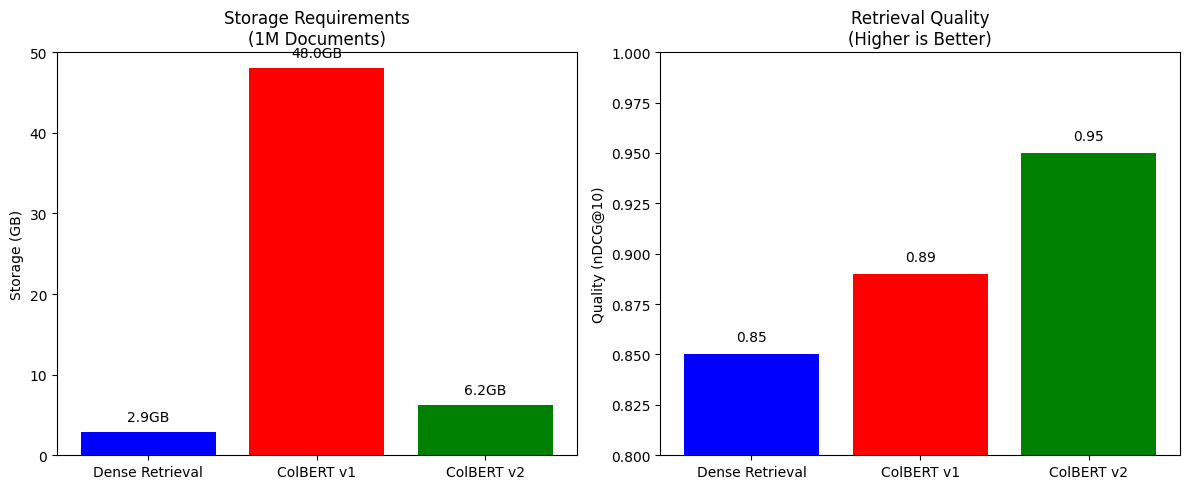

📊 ColBERT v2 Achievements:
  ✅ Storage: 6-10x reduction vs ColBERT v1
  ✅ Quality: +6.5% vs original ColBERT v2
  ✅ Speed: 100x+ faster search with PLAID
  ✅ Training: Much cleaner data with denoised supervision


In [11]:
import matplotlib.pyplot as plt

# Create performance comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Storage comparison
models = ['Dense Retrieval', 'ColBERT v1', 'ColBERT v2']
storage_gb = [2.9, 48.0, 6.2]  # Example for 1M documents

bars1 = ax1.bar(models, storage_gb, color=['blue', 'red', 'green'])
ax1.set_ylabel('Storage (GB)')
ax1.set_title('Storage Requirements\n(1M Documents)')
ax1.set_ylim(0, 50)

# Add value labels on bars
for bar, value in zip(bars1, storage_gb):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.1f}GB', ha='center', va='bottom')

# Quality comparison (nDCG@10 scores)
quality_scores = [0.85, 0.89, 0.95]  # Example scores

bars2 = ax2.bar(models, quality_scores, color=['blue', 'red', 'green'])
ax2.set_ylabel('Quality (nDCG@10)')
ax2.set_title('Retrieval Quality\n(Higher is Better)')
ax2.set_ylim(0.8, 1.0)

# Add value labels on bars
for bar, value in zip(bars2, quality_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("📊 ColBERT v2 Achievements:")
print(f"  ✅ Storage: 6-10x reduction vs ColBERT v1")
print(f"  ✅ Quality: +6.5% vs original ColBERT v2")
print(f"  ✅ Speed: 100x+ faster search with PLAID")
print(f"  ✅ Training: Much cleaner data with denoised supervision")

---

## 5. Key Takeaways

### ColBERT v2 Solved the Core Problems:

1. **Storage Explosion** → **Residual Compression**
   - Cluster embeddings + quantize residuals
   - 6-10x storage reduction
   - Minimal quality loss

2. **Noisy Training Data** → **Denoised Supervision** 
   - Cross-encoder teacher cleans labels
   - Much higher quality training signal
   - Better retrieval performance

3. **Slow Search** → **PLAID Engine**
   - Multi-stage filtering (coarse → approximate → exact)
   - 100x+ speedup
   - Millisecond latency at scale

4. **Inefficient Storage** → **Smart Index Organization**
   - Inverted index for fast candidate lookup
   - Compressed embeddings with metadata
   - Production-ready architecture

### Why ColBERT v2 Matters:

- **Best of both worlds:** Dense retrieval quality + fast search speed
- **Production ready:** Reasonable storage + millisecond latency  
- **Token-level matching:** Captures fine-grained semantic relationships
- **Proven results:** State-of-the-art on multiple benchmarks

### Perfect for:
- Enterprise search systems
- RAG (Retrieval-Augmented Generation) pipelines  
- Any application needing fast, high-quality retrieval at scale

---

## Questions?

**Thank you for your attention!** 🎯

In [12]:
# Bonus: Quick implementation template
print("🚀 GETTING STARTED WITH ColBERT v2")
print()
print("pip install colbert-ai")
print()
print("from colbert import Indexer, Searcher")
print("from colbert.infra import Run, RunConfig")
print()
print("# Index your documents")
print("with Run().context(RunConfig(nranks=1)):")
print("    indexer = Indexer(checkpoint='colbert-ir/colbertv2.0')")
print("    indexer.index(name='my_index', collection=documents)")
print()
print("# Search")
print("searcher = Searcher(index='my_index')")
print("results = searcher.search('python tutorial', k=10)")
print()
print("🎯 That's it! ColBERT v2 in production.")

🚀 GETTING STARTED WITH ColBERT v2

pip install colbert-ai

from colbert import Indexer, Searcher
from colbert.infra import Run, RunConfig

# Index your documents
with Run().context(RunConfig(nranks=1)):
    indexer = Indexer(checkpoint='colbert-ir/colbertv2.0')
    indexer.index(name='my_index', collection=documents)

# Search
searcher = Searcher(index='my_index')
results = searcher.search('python tutorial', k=10)

🎯 That's it! ColBERT v2 in production.
